In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#1. Load Health Data
df_health = pd.read_csv('../data/raw/synthetic_coffee_health_10000.csv')

In [3]:
#2. Check the distributions
print(f"Loaded {df_health.shape[0]} patient records.")

Loaded 10000 patient records.


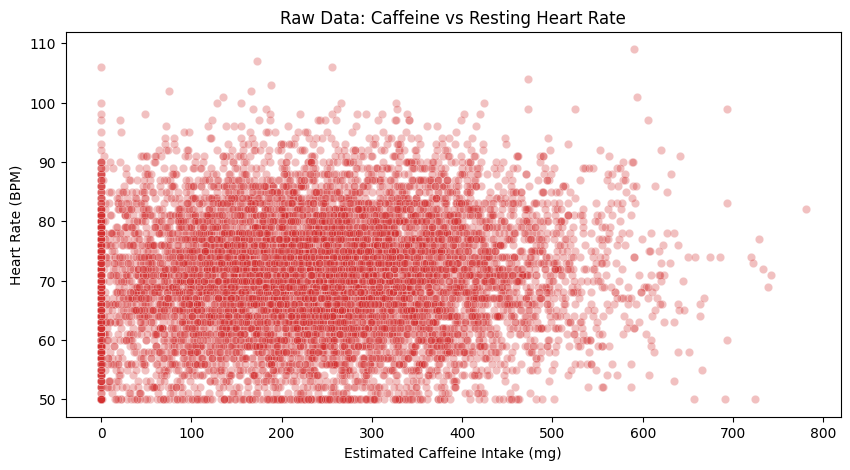

In [4]:
#3. quick visualization of the raw data found
plt.figure(figsize=(10,5))
sns.scatterplot(data=df_health, x='Caffeine_mg', y='Heart_Rate', alpha=0.3, color='#D32F2F')
plt.title("Raw Data: Caffeine vs Resting Heart Rate")
plt.xlabel("Estimated Caffeine Intake (mg)")
plt.ylabel("Heart Rate (BPM)")
plt.show()

In [5]:
# We will split the data into training and testing sets, then use a `RandomForestRegressor`. I am setting `max_depth=5` to prevent the model from over-complicating the relationship.
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [6]:
#1. Define features (XX) and target (y)
X = df_health[['Caffeine_mg']]
y = df_health['Heart_Rate']

#2. Split into 80% training and 20% testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
#3. initialize and train the random forest
print("Training the Biological Model..")
pulse_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
pulse_model.fit(X_train, y_train)

Training the Biological Model..


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [8]:
#4. Evaluate the model
y_pred = pulse_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)

In [9]:
print(f"Model Trained! Mean Absolute Error: {mae:.2f} BPM")
# A low MAE means your model's predicted heartbeat is highly accurate!

Model Trained! Mean Absolute Error: 7.98 BPM


In [10]:
# Let's plot a clean trend line of what your model actually learned. This line is exactly what will power the interactive Dash slider.
import numpy as np
# Generate a smooth range of caffeine values from 0 to 500mg
x_range = np.linspace(0, 500, 100).reshape(-1,1)

In [11]:
# Predict the Heart Rate for each theoretical caffeine amount
# (Using a dataframe with the exact column name to avoid sklearn warnings)
x_range_df = pd.DataFrame(x_range, columns=['Caffeine_mg'])
y_smooth_pred = pulse_model.predict(x_range_df)

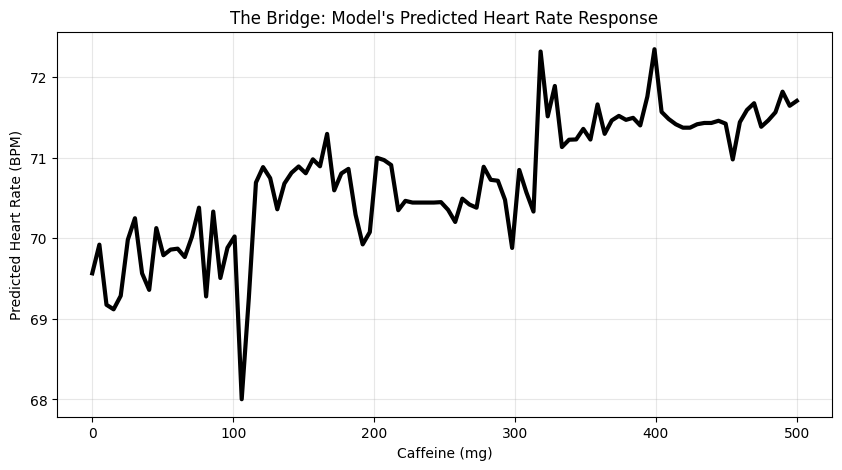

In [12]:
plt.figure(figsize=(10, 5))
sns.lineplot(x=x_range.flatten(), y=y_smooth_pred, color='black', linewidth=3)
plt.title("The Bridge: Model's Predicted Heart Rate Response")
plt.xlabel("Caffeine (mg)")
plt.ylabel("Predicted Heart Rate (BPM)")
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
#Finally, we serialize (save) the trained model so your `app.py` can load it instantly without having to retrain it every time a user visits your portfolio.

import joblib
import os

In [14]:
# ensure the models directory exists
# os.makedirs('../models', exist_ok=True)

In [15]:
# Save the model
joblib.dump(pulse_model, '../models/pulse_model.pkl')
print("Model successfully saved to: models/pulse_model.pkl")

Model successfully saved to: models/pulse_model.pkl
